DATA VIZ PROJECT : Exploration Multispectrale des Côtes Atlantiques Marocaines -- GOOLE EARTH ENGINE

In [9]:
pip install earthengine-api geemap


In [10]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import ee
import geemap

In [11]:
ee.Authenticate()

True

In [12]:
ee.Initialize()

In [13]:
sentinel2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')

In [ ]:
agadir = ee.Geometry.Rectangle([-9.7, 30.27, -9.45, 30.47])


collection1 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(agadir)
    .filterDate("2023-01-01", "2023-12-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
)

image1 = collection1.median()

# --- Indices ---
ndvi = image1.normalizedDifference(['B8','B4']).rename('NDVI')
ndwi = image1.normalizedDifference(['B3','B8']).rename('NDWI')
mndwi = image1.normalizedDifference(['B3', 'B11']).rename('MNDWI')
ndbi = image1.normalizedDifference(['B11','B8']).rename('NDBI')

bsi = image1.expression(
    '((B11 + B4) - (B8 + B2)) / ((B11 + B4) + (B8 + B2))',
    {'B11': image1.select('B11'),
     'B4': image1.select('B4'),
     'B8': image1.select('B8'),
     'B2': image1.select('B2')}
).rename('BSI')

# --- Ratios ---
ratio1 = image1.select('B2').divide(image1.select('B3')).rename('B2_B3')
ratio2 = image1.select('B3').divide(image1.select('B4')).rename('B3_B4')
ratio3 = image1.select('B8').divide(image1.select('B4')).rename('B8_B4')
ratio4 = image1.select('B11').divide(image1.select('B8')).rename('B11_B8')

# --- Log bands ---
logB2 = image1.select('B2').log().rename('logB2')
logB8 = image1.select('B8').log().rename('logB8')

# ---- GLCM ----
b8_uint8 = image1.select('B8').multiply(255).divide(3000).clamp(0,255).toUint8()
glcm = b8_uint8.glcmTexture(size=3)
glcm_b8_contrast = glcm.select('B8_contrast')

# ---- Assemble FULL image ----
full = image1.select(['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12']) \
    .addBands([ndvi, ndwi, mndwi, ndbi, bsi]) \
    .addBands([ratio1, ratio2, ratio3, ratio4]) \
    .addBands([logB2, logB8]) \
    .addBands([glcm_b8_contrast]) \
    .float()  


In [20]:
samples1 =full.sample(
    region=agadir,
    scale=20,
    numPixels=50000,
    geometries=False
)

In [ ]:
task = ee.batch.Export.table.toDrive(
    collection=samples1,   
    description='agadir_sentinel_samples',
    fileFormat='CSV'
)
task.start()



In [22]:
task.status()

{'state': 'READY',
 'description': 'agadir_sentinel_samples',
 'priority': 100,
 'creation_timestamp_ms': 1763413650495,
 'update_timestamp_ms': 1763413650495,
 'start_timestamp_ms': 0,
 'task_type': 'EXPORT_FEATURES',
 'id': '7OMPWOLH3EPGK4AG3GCNJW66',
 'name': 'projects/637410919922/operations/7OMPWOLH3EPGK4AG3GCNJW66'}

In [23]:

df = pd.read_csv("C:/Users/Dell/Downloads/agadir_sentinel_samples.csv")  # adapte le chemin





In [24]:
print(df.isnull().sum())
df.describe()

system:index    0
B1              0
B11             0
B11_B8          0
B12             0
B2              0
B2_B3           0
B3              0
B3_B4           0
B4              0
B5              0
B6              0
B7              0
B8              0
B8A             0
B8_B4           0
B8_contrast     0
B9              0
BSI             0
MNDWI           0
NDBI            0
NDVI            0
NDWI            0
logB2           0
logB8           0
.geo            0
dtype: int64


,system:index,B1,B11,B11_B8,B12,B2,B2_B3,B3,B3_B4,B4,...,B8_B4,B8_contrast,B9,BSI,MNDWI,NDBI,NDVI,NDWI,logB2,logB8
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,786.429380,2469.879925,1.080595,2167.351261,928.283668,0.808006,1243.837218,1.063446,1582.398505,...,1.249417,349.836958,2138.279411,0.038558,-0.111730,0.028147,0.068708,-0.085512,6.674967,7.081303
std,14433.901067,373.728014,1712.777585,0.213571,1527.798865,514.430037,0.164105,732.313301,0.486896,1083.549028,...,0.619839,613.414744,1444.671674,0.180345,0.404655,0.104107,0.178243,0.344782,0.574762,1.362456
min,0.000000,216.307693,102.333336,0.320103,99.099998,108.000000,0.345466,173.833328,0.514925,155.466660,...,0.392411,0.000000,71.555557,-0.383117,-0.732491,-0.515034,-0.436357,-0.739946,4.682131,4.707727
25%,12499.750000,411.866669,145.428574,0.896889,119.800003,413.097733,0.684233,433.750000,0.717997,238.250000,...,0.825879,1.086310,111.800003,-0.189182,-0.431054,-0.054358,-0.095363,-0.342076,6.023684,5.169672
50%,24999.500000,748.816650,3030.291626,1.110807,2656.500000,877.154785,0.742506,1272.583313,0.778160,1776.000000,...,1.245528,87.815475,2716.541748,0.131501,-0.315092,0.052495,0.109341,-0.249814,6.776684,7.867871
75%,37499.250000,1093.000000,3661.000000,1.247791,3307.000000,1265.643921,0.933804,1744.666626,1.627667,2386.000000,...,1.431545,432.263878,3179.000000,0.183522,0.407991,0.110238,0.177478,0.357406,7.143336,8.058960
max,49999.000000,2915.833252,7383.000000,3.350294,6727.000000,4656.000000,1.360570,5490.399902,2.811207,5967.200195,...,11.843037,10215.679688,6130.000000,0.404411,0.689563,0.540261,0.844274,0.653732,8.445912,8.796944


In [1]:


Map = geemap.Map(center=[30.4, -9.6], zoom=11)  # Agadir
Map.addLayer(agadir, {}, "Agadir Region")        # rectangle de la zone

# Visualiser l'image médiane avec RGB naturel
vis_params = {
    'bands': ['B4', 'B3', 'B2'],  # R, G, B
    'min': 0,
    'max': 3000,
    'gamma': 1.2
}
Map.addLayer(image1, vis_params, 'Sentinel-2 RGB')

Map


NameError: name 'geemap' is not defined

In [28]:
df['zone'] = 'Mer'
df.loc[(df['NDWI'] > -0.05) & (df['NDWI'] <= 0.2), 'zone'] = 'Plage'
df.loc[(df['NDWI'] <= -0.05), 'zone'] = 'Terre'



In [29]:
df_mer = df[df['zone'] == 'Mer']
df_plage = df[df['zone'] == 'Plage']


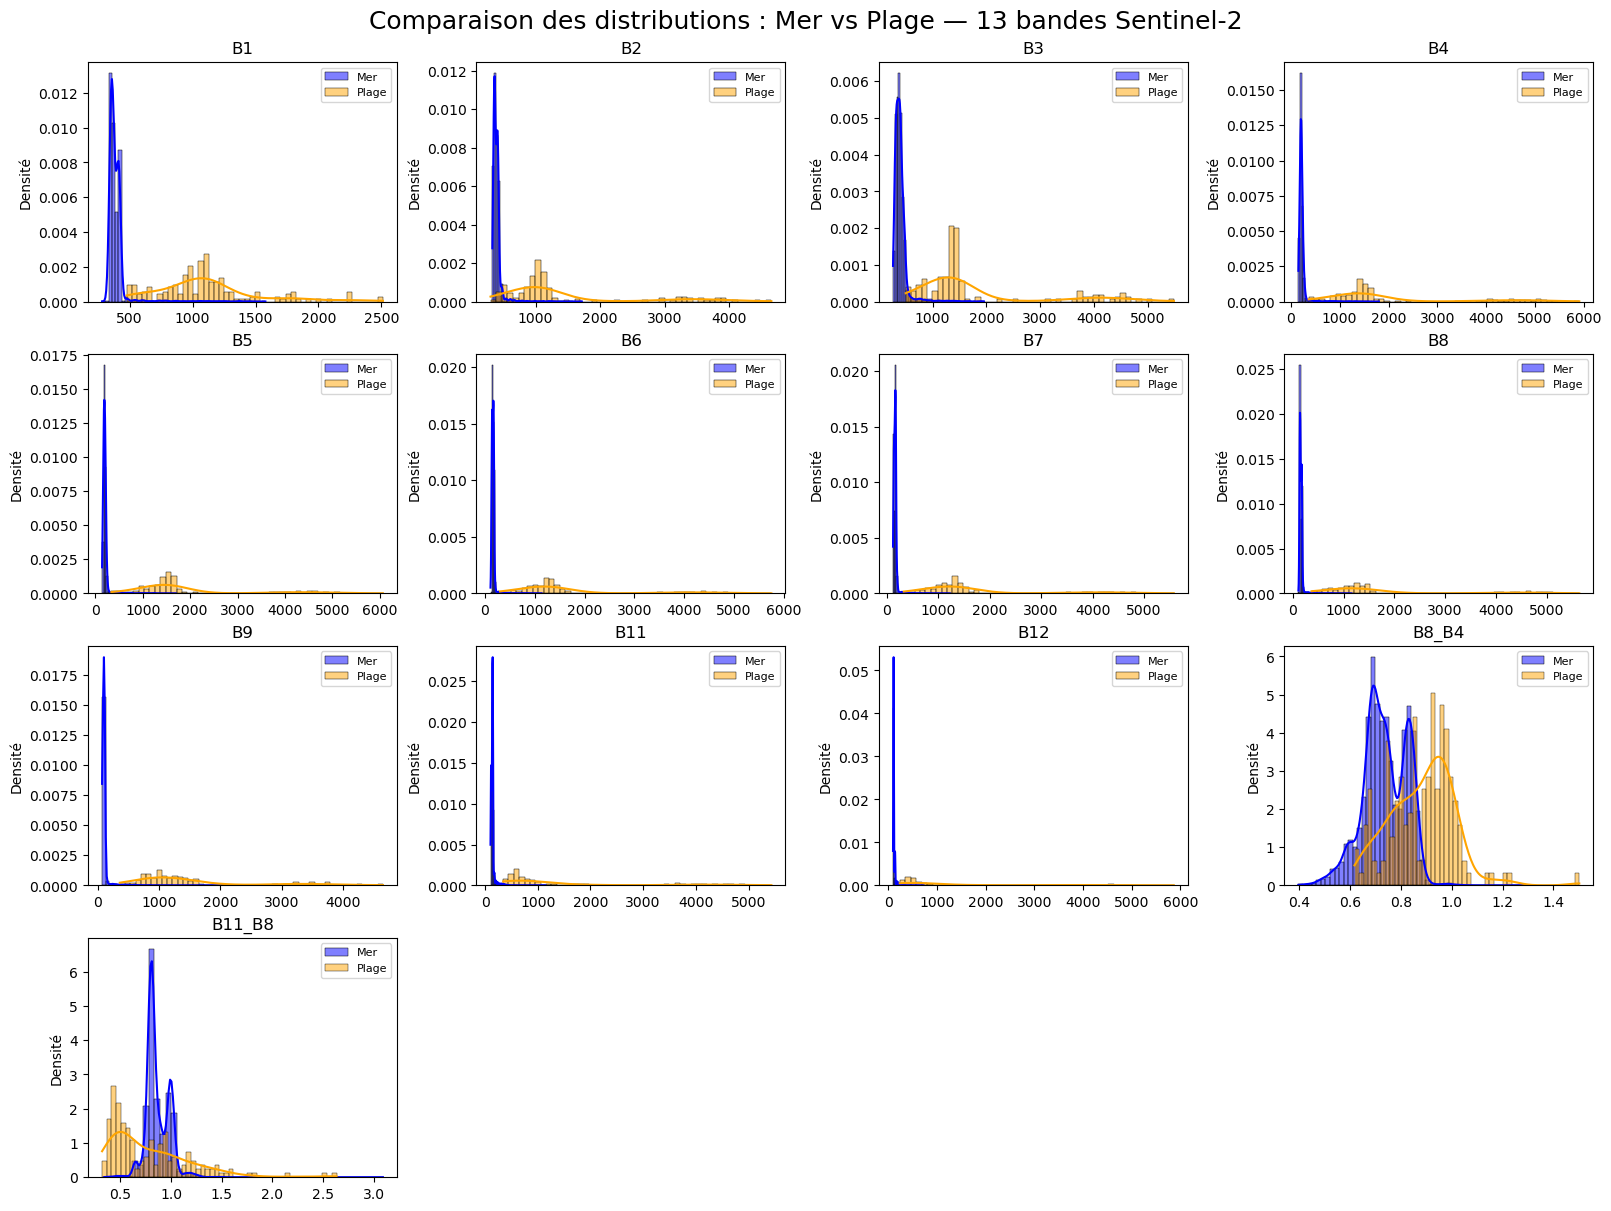

In [30]:

cols = [
    'B1','B2','B3','B4','B5','B6','B7',
    'B8','B9','B11','B12','B8_B4','B11_B8'
]


n_sample = 8000
df_mer_s = df_mer.sample(min(len(df_mer), n_sample), random_state=42)
df_plage_s = df_plage.sample(min(len(df_plage), n_sample), random_state=42)


n = len(cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), constrained_layout=True)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    sns.histplot(df_mer_s[col], 
                 bins=50, alpha=0.5, stat='density', color='blue', kde=True,
                 label='Mer', ax=ax)
    sns.histplot(df_plage_s[col], 
                 bins=50, alpha=0.5, stat='density', color='orange', kde=True,
                 label='Plage', ax=ax)
    
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("Densité")

# Supprimer axes vides si < 4 × 4
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Comparaison des distributions : Mer vs Plage — 13 bandes Sentinel-2", fontsize=18)
plt.show()


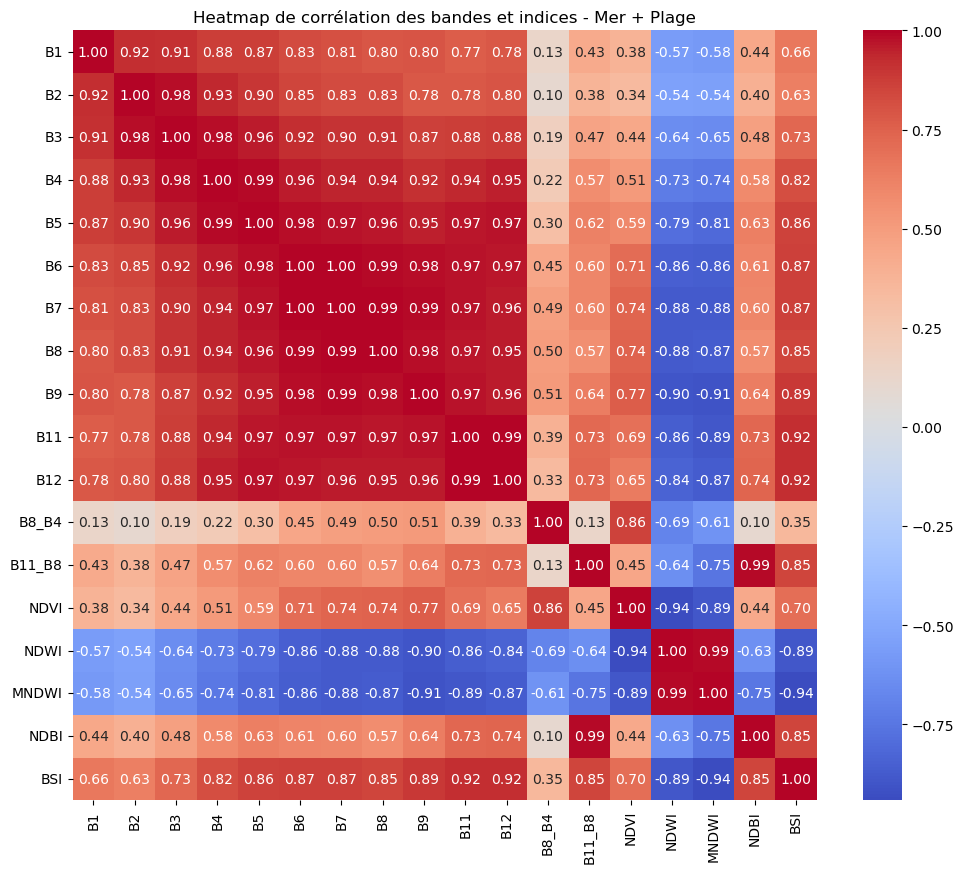

In [31]:

cols = [
    'B1','B2','B3','B4','B5','B6','B7',
    'B8','B9','B11','B12','B8_B4','B11_B8','NDVI','NDWI','MNDWI','NDBI','BSI'
]

# Calculer la matrice de corrélation pour Mer + Plage
corr_matrix = df[cols].corr()

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Heatmap de corrélation des bandes et indices - Mer + Plage")
plt.show()


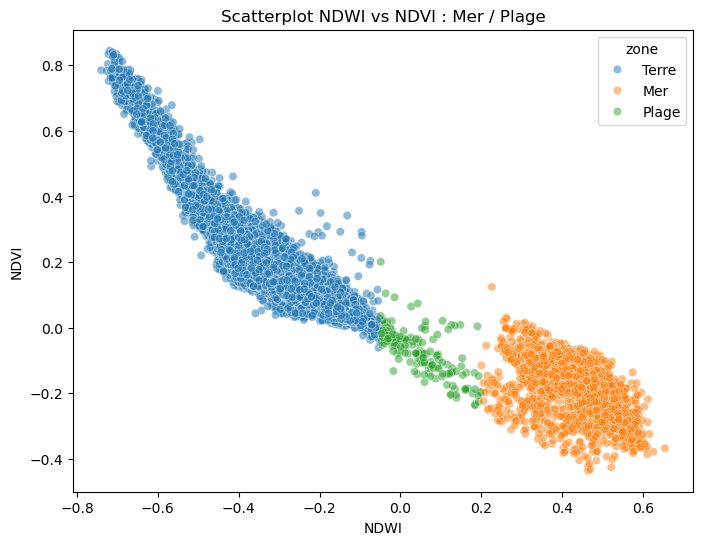

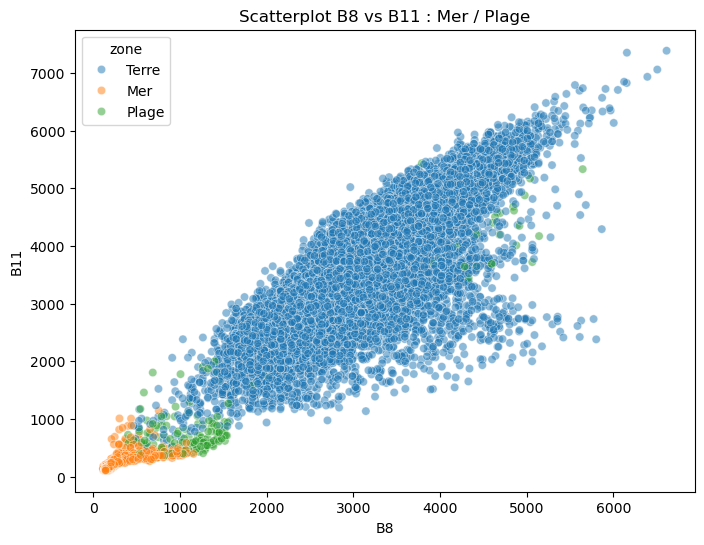

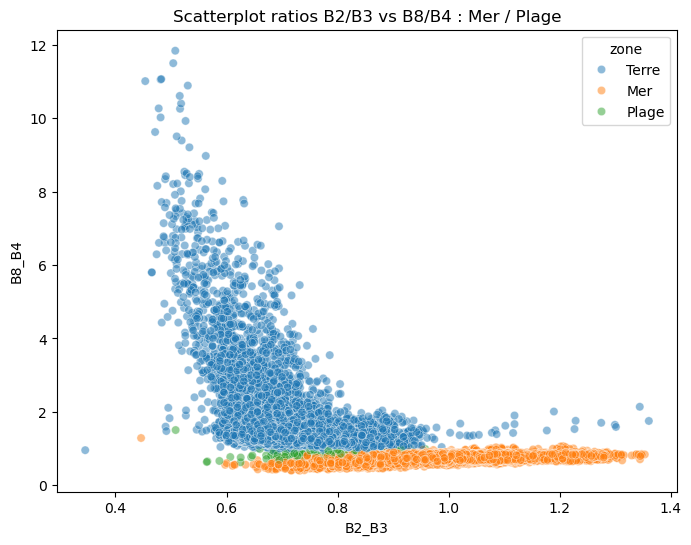

In [32]:
# Scatterplot NDWI vs NDVI
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='NDWI', y='NDVI', hue='zone', alpha=0.5)
plt.title("Scatterplot NDWI vs NDVI : Mer / Plage")
plt.show()

# Scatterplot B8 vs B11
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='B8', y='B11', hue='zone', alpha=0.5)
plt.title("Scatterplot B8 vs B11 : Mer / Plage")
plt.show()

# Scatterplot B2_B3 vs B8_B4
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='B2_B3', y='B8_B4', hue='zone', alpha=0.5)
plt.title("Scatterplot ratios B2/B3 vs B8/B4 : Mer / Plage")
plt.show()


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Colonnes choisies
pca_cols = ['B1','B2','B3','B4','B5','B6','B7','B8','B9','NDWI','MNDWI','NDVI','BSI']

# Sélection des zones mer + plage
df_pca = df[df['zone'].isin(['Mer','Plage'])][pca_cols]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)


Variance expliquée par chaque composante :
[0.69525462 0.1639     0.08139353 0.02609884]


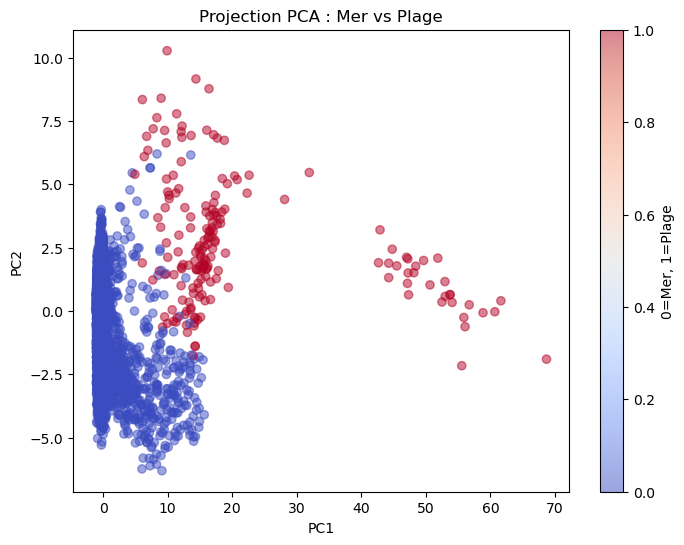

In [ ]:
# Nombre de composantes à commencer 
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
print("Variance expliquée par chaque composante :")
print(pca.explained_variance_ratio_)

# Visualisation 2D des deux premières composantes
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df[df['zone'].isin(['Mer','Plage'])]['zone'].map({'Mer':0,'Plage':1}), cmap='coolwarm', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection PCA : Mer vs Plage')
plt.colorbar(label='0=Mer, 1=Plage')
plt.show()


In [35]:
pip install umap-learn


Note: you may need to restart the kernel to use updated packages.


In [36]:
import umap

In [37]:
import umap


# Suppose X_pca contient les 5 premières composantes PCA
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_pca)



umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
umap_df['zone'] = df[df['zone'].isin(['Mer','Plage'])]['zone'].values


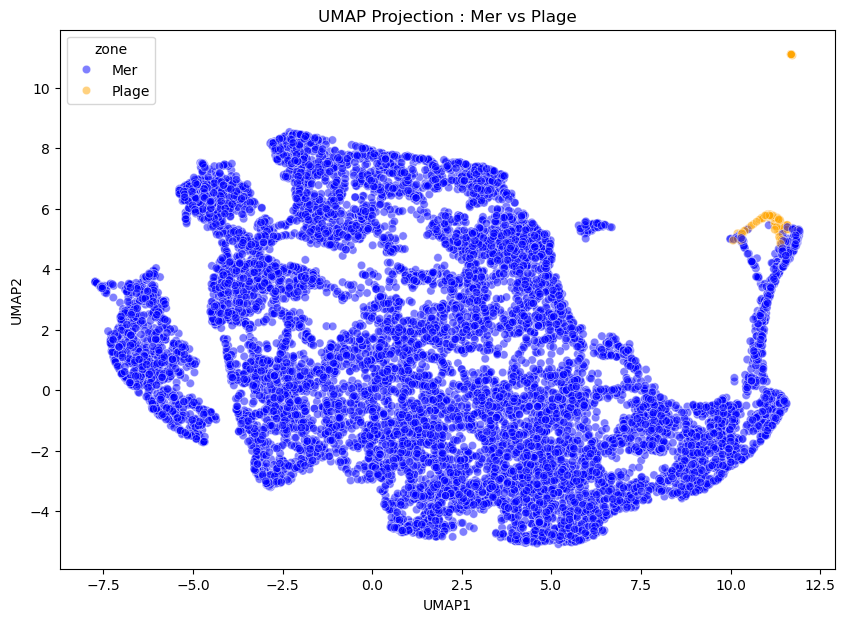

In [39]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='zone', alpha=0.5, palette={'Mer':'blue','Plage':'orange'})
plt.title("UMAP Projection : Mer vs Plage")
plt.show()


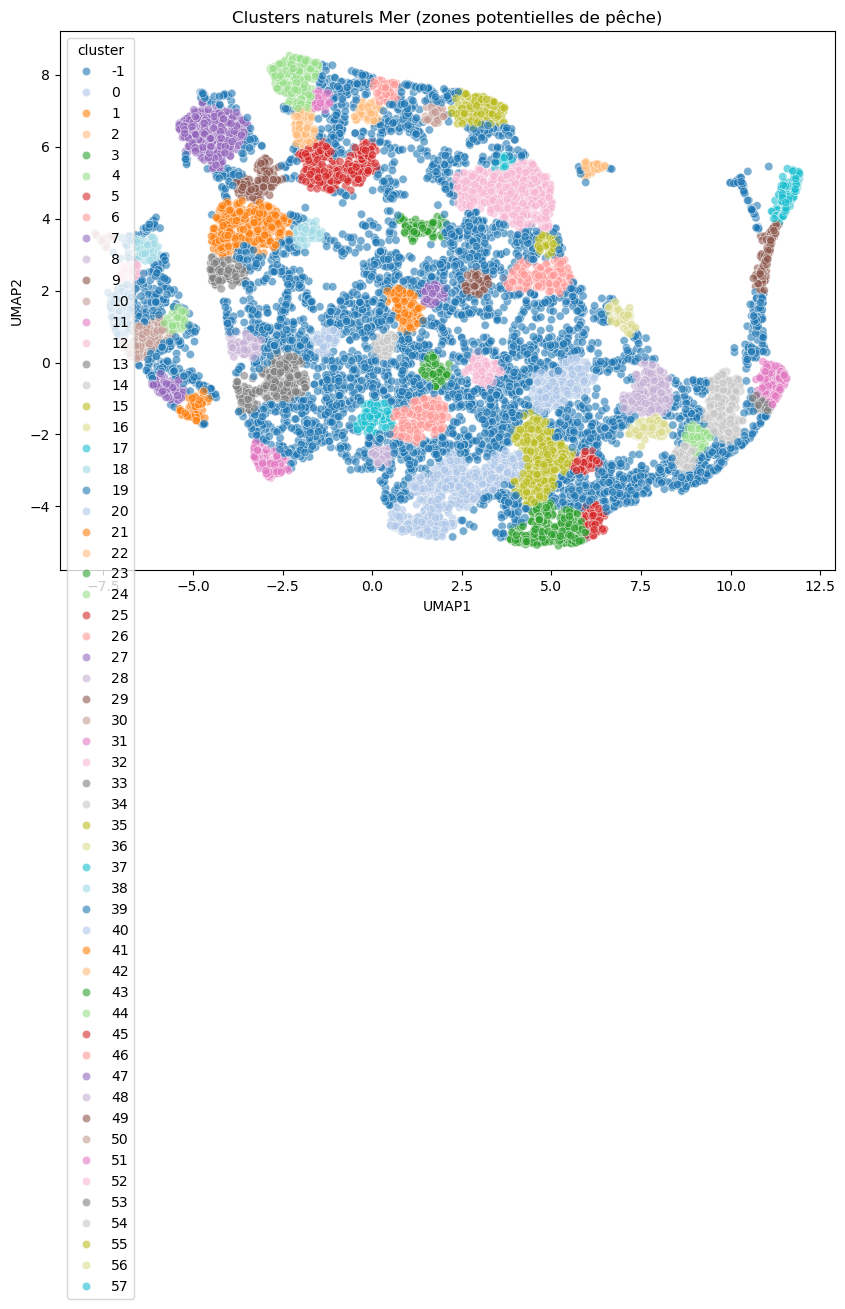

In [40]:
from sklearn.cluster import DBSCAN

# Filtrer uniquement les pixels mer
mer_umap = umap_df[umap_df['zone']=='Mer'][['UMAP1','UMAP2']]

# DBSCAN pour clusters naturels
db = DBSCAN(eps=0.3, min_samples=50)
mer_umap['cluster'] = db.fit_predict(mer_umap)

# Visualisation
plt.figure(figsize=(10,7))
sns.scatterplot(data=mer_umap, x='UMAP1', y='UMAP2', hue='cluster', palette='tab20', alpha=0.6)
plt.title("Clusters naturels Mer (zones potentielles de pêche)")
plt.show()


In [ ]:


# --- 1. PRÉPARATION DU DATAFRAME DES RÉFLECTANCES MARINES ---

df_mer_base = df[df['zone'] == 'Mer'].copy()


df_mer_base['cluster'] = mer_umap['cluster'] 


# --- 2. CALCUL DES PROXYS DE PRODUCTIVITÉ ---
# Proxy Chlorophylle-a (Productivité) : B3/B2. Plus élevé = plus productif.
df_mer_base['Proxy_ChlA'] = df_mer_base['B3'] / df_mer_base['B2'] 

# Proxy Turbidité (via SWIR) : B8/B4 ou B8/B11 peut être utilisé.
# Nous utilisons B4 car B8 et B4 sont deux sources de variation importantes en mer.
df_mer_base['Proxy_Turbidity'] = df_mer_base['B8'] / df_mer_base['B4']


# --- 3. REGROUPEMENT ET ANALYSE DES MOYENNES PAR CLUSTER ---
# On exclut le cluster '-1' (Bruit) pour l'analyse statistique des centres.

bands_and_proxies = ['B2', 'B3', 'B4', 'B8', 'B11', 'Proxy_ChlA', 'Proxy_Turbidity']

cluster_analysis = (
    df_mer_base[df_mer_base['cluster'] != -1]
    .groupby('cluster')
    [bands_and_proxies]
    .mean()
    .reset_index()
)

# Trier par la productivité (Proxy_ChlA) en ordre décroissant
cluster_analysis_sorted = cluster_analysis.sort_values(by='Proxy_ChlA', ascending=False)

print("--- Analyse des Clusters triée par Proxy Chl-a (Productivité) ---")
print(cluster_analysis_sorted.head(10)) # Afficher les 10 clusters les plus productifs

--- Analyse des Clusters triée par Proxy Chl-a (Productivité) ---
    cluster          B2          B3          B4          B8         B11  \
56     57.0  416.221867  442.216923  236.394417  176.404742  156.989313   
48     48.0  450.727314  476.568190  286.008657  198.014979  153.521949   
45     45.0  395.401399  411.801109  229.778837  162.532571  136.492278   
2       2.0  388.370186  401.183433  221.557456  160.305768  145.309358   
4       4.0  405.220543  418.708356  225.473180  158.649252  145.196562   
17     17.0  411.917974  425.877520  254.814774  180.688350  154.200342   
14     14.0  391.860308  399.064419  209.252370  154.575819  136.282291   
29     29.0  408.602575  421.711370  248.952719  178.680655  152.316032   
33     33.0  412.353533  422.456630  252.457800  176.286653  143.901902   
34     34.0  401.696813  410.287743  229.997102  162.121850  139.482447   

    Proxy_ChlA  Proxy_Turbidity  
56    1.049557         0.756706  
48    1.033463         0.722164  
45    

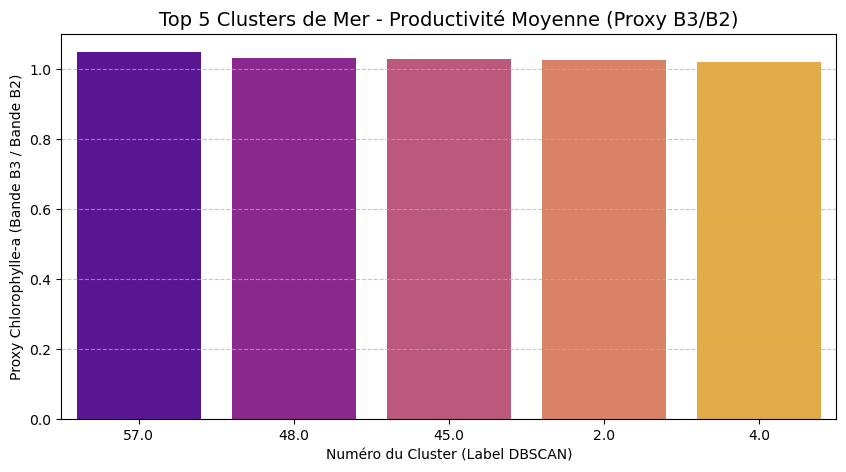

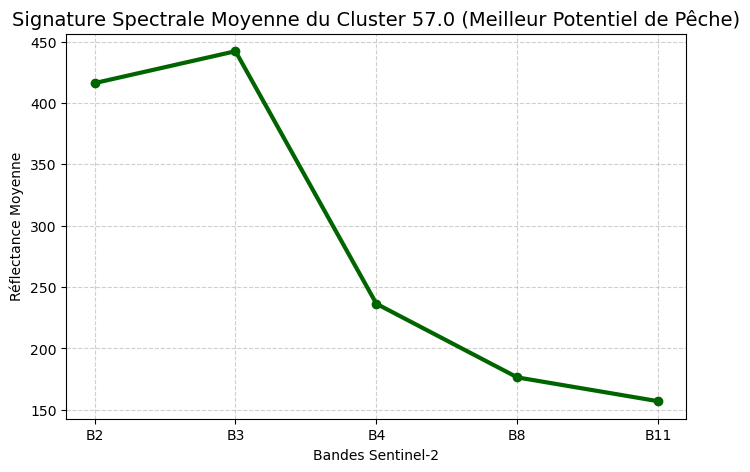

In [43]:


# --- A. VISUALISATION DES CLUSTERS LES PLUS PRODUCTIFS (BARRES) ---
top_n = 5
plot_data = cluster_analysis_sorted.head(top_n).copy() # Les 5 meilleurs clusters

plt.figure(figsize=(10, 5))
# Utilisation d'une palette qui montre une gradation (ex: plasma)
sns.barplot(x='cluster', y='Proxy_ChlA', data=plot_data, palette='plasma', order=plot_data['cluster']) 

plt.title(f"Top {top_n} Clusters de Mer - Productivité Moyenne (Proxy B3/B2)", fontsize=14)
plt.xlabel("Numéro du Cluster (Label DBSCAN)")
plt.ylabel("Proxy Chlorophylle-a (Bande B3 / Bande B2)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# --- B. VISUALISATION DE LA SIGNATURE SPECTRALE DU MEILLEUR CLUSTER ---
# Le cluster le plus productif est le premier de la liste triée
best_cluster_id = cluster_analysis_sorted['cluster'].iloc[0]
best_cluster_signature = cluster_analysis_sorted.iloc[0][['B2', 'B3', 'B4', 'B8', 'B11']].to_list()
bands_labels = ['B2', 'B3', 'B4', 'B8', 'B11']

plt.figure(figsize=(8, 5))
plt.plot(bands_labels, best_cluster_signature, marker='o', linestyle='-', color='darkgreen', linewidth=3)
plt.title(f"Signature Spectrale Moyenne du Cluster {best_cluster_id} (Meilleur Potentiel de Pêche)", fontsize=14)
plt.xlabel("Bandes Sentinel-2")
plt.ylabel("Réflectance Moyenne")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()